In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS, Isomap, TSNE
import umap
import seaborn as sns
import colorcet as cc
from sklearn.decomposition import PCA 

In [112]:
plt.rcParams.update({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7
})

cm_to_inch = 1 / 2.54
figsize_cm = (8 * cm_to_inch, 8 * cm_to_inch)  # (9cm, 9cm)
fig_size = figsize_cm
fig_args = {"figsize":fig_size}
tick_args = {"pad":0}
lable_args = {"labelpad" : -5}
save_args = {"bbox_inches":'tight', "dpi":300}

In [28]:
# be careful, for the heading line (~4 lines) show relative information not the true rmsd
#### Time (ps) (xaxis) data were shown below, from left to right: remove 
#### Time (ps) (yaxis) data were shown below, from top to bottom:
#### Time (ps) (yaxis) data were shown below, from bottom to top: remove
#### RMSD (nm) (figure dots) data were shown below, from top to bottom, from left to right:

data_file = 'wl.dat'
df = pd.read_csv(data_file, delimiter = ',')

col_index = [str(i * 100) for i in range(2501)]
row_index = [str(i * 100) for i in range(2500,-1,-1)]

df.index = row_index
df.columns = col_index

,0,100,200,300,400,500,600,700,800,900,...,249100,249200,249300,249400,249500,249600,249700,249800,249900,250000
250000,2.420,2.420,2.420,2.500,2.50,2.59,2.59,2.67,2.59,2.67,...,0.173,0.173,0.173,0.173,0.1730,0.1730,0.2590,0.173,0.173,0.00
249900,2.500,2.500,2.500,2.500,2.59,2.59,2.59,2.67,2.67,2.67,...,0.173,0.173,0.173,0.173,0.0863,0.0863,0.0863,0.173,0.000,3.36
249800,2.500,2.500,2.500,2.590,2.59,2.67,2.67,2.67,2.67,2.67,...,0.173,0.173,0.173,0.173,0.1730,0.1730,0.1730,0.000,3.360,3.36
249700,2.500,2.500,2.500,2.590,2.59,2.67,2.67,2.67,2.67,2.67,...,0.173,0.173,0.173,0.173,0.1730,0.1730,0.0000,3.360,3.360,3.36
249600,2.420,2.420,2.420,2.500,2.50,2.59,2.59,2.59,2.59,2.67,...,0.173,0.173,0.173,0.173,0.0863,0.0000,3.3600,3.360,3.360,3.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,0.431,0.345,0.259,0.173,0.00,3.36,3.36,3.36,3.36,3.36,...,0.000,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.000,0.000,0.00
300,0.431,0.345,0.173,0.000,3.36,3.36,3.36,3.36,3.36,3.36,...,0.000,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.000,0.000,0.00
200,0.431,0.259,0.000,3.360,3.36,3.36,3.36,3.36,3.36,3.36,...,0.000,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.000,0.000,0.00
100,0.345,0.000,3.360,3.360,3.36,3.36,3.36,3.36,3.36,3.36,...,0.000,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.000,0.000,0.00


In [45]:
center_point = []
df_reversed = df[::-1]

# why there is not symmetric array, 
# for the dat: the left upper triangle is the rmsd matrix
# for the df: the left lower is the rmsd matrix
distance_matrix = df_reversed.to_numpy()
# print(distance_matrix)
N = distance_matrix.shape[0]
rows, cols =  np.triu_indices(N, k=1)
# print(rows, cols)
distance_matrix[rows, cols] = distance_matrix[cols, rows]
distance_matrix
# print(distance_matrix)

,0,100,200,300,400,500,600,700,800,900,...,249100,249200,249300,249400,249500,249600,249700,249800,249900,250000
0,0.000,3.360,0.431,0.431,0.431,0.518,0.518,0.431,0.431,0.431,...,2.420,2.500,2.420,2.500,2.4200,2.4200,2.5000,2.500,2.5000,2.420
100,0.345,0.000,3.360,0.345,0.345,0.518,0.518,0.518,0.431,0.431,...,2.500,2.500,2.500,2.500,2.5000,2.4200,2.5000,2.500,2.5000,2.420
200,0.431,0.259,0.000,3.360,0.259,0.431,0.518,0.431,0.345,0.345,...,2.420,2.500,2.420,2.500,2.4200,2.4200,2.5000,2.500,2.5000,2.420
300,0.431,0.345,0.173,0.000,3.360,0.345,0.431,0.345,0.259,0.345,...,2.500,2.590,2.500,2.590,2.5000,2.5000,2.5900,2.590,2.5000,2.500
400,0.431,0.345,0.259,0.173,0.000,3.360,0.345,0.345,0.259,0.345,...,2.500,2.590,2.500,2.590,2.5900,2.5000,2.5900,2.590,2.5900,2.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249600,2.420,2.420,2.420,2.500,2.500,2.590,2.590,2.590,2.590,2.670,...,0.173,0.173,0.173,0.173,0.0863,0.0000,3.3600,0.173,0.0863,0.173
249700,2.500,2.500,2.500,2.590,2.590,2.670,2.670,2.670,2.670,2.670,...,0.173,0.173,0.173,0.173,0.1730,0.1730,0.0000,3.360,0.0863,0.259
249800,2.500,2.500,2.500,2.590,2.590,2.670,2.670,2.670,2.670,2.670,...,0.173,0.173,0.173,0.173,0.1730,0.1730,0.1730,0.000,3.3600,0.173
249900,2.500,2.500,2.500,2.500,2.590,2.590,2.590,2.670,2.670,2.670,...,0.173,0.173,0.173,0.173,0.0863,0.0863,0.0863,0.173,0.0000,3.360


In [49]:
# reduce the distance matrix to a 2-d coords
mds = MDS(n_components=2, random_state=42, dissimilarity='precomputed') 
coords = mds.fit_transform(distance_matrix)

D:\miniconda3\envs\plot\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


In [132]:
# for the different
# get plot df
plot_df = pd.DataFrame({'x':coords[:,0], 'y':coords[:,1], 'cluster':[0] * 2501})
plot_df.index = df_reversed.index

print(coords,plot_df)

[[-1.40467627  1.02403038]
 [-1.46872768  1.00121897]
 [-1.52395063  0.92067043]
 ...
 [ 0.04155757 -0.86760636]
 [ 0.10493335 -0.81762334]
 [ 0.08906338 -0.79331751]]                x         y  cluster
0      -1.404676  1.024030        0
100    -1.468728  1.001219        0
200    -1.523951  0.920670        0
300    -1.579926  0.987560        0
400    -1.556904  1.028942        0
...          ...       ...      ...
249600  0.127567 -0.730553        0
249700  0.064524 -0.840374        0
249800  0.041558 -0.867606        0
249900  0.104933 -0.817623        0
250000  0.089063 -0.793318        0

[2501 rows x 3 columns]


In [138]:
log_file = 'D:/Desktop/clustering_analysis/clustering_analysis/wl_model_1/cluster.log'
result = parse_gromos_cluster_log(log_file)
for cl_id, members_list in result.items():
    # print(cl_id)
    # print(members_list)
    for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'
print(plot_df)

               x         y cluster
0      -1.404676  1.024030       2
100    -1.468728  1.001219       2
200    -1.523951  0.920670       2
300    -1.579926  0.987560       2
400    -1.556904  1.028942       2
...          ...       ...     ...
249600  0.127567 -0.730553       1
249700  0.064524 -0.840374       1
249800  0.041558 -0.867606       1
249900  0.104933 -0.817623       1
250000  0.089063 -0.793318       1

[2501 rows x 3 columns]


In [142]:
center_index = [153400, 33600,58500,76600,23100,46200,174400,4500,21600,48000,88700]
hue_order = [f'{i}' for i in range(1,len(result)+1)]
center_df  = pd.DataFrame({'x':[plot_df.loc[f'{index}','x'] for index in center_index],
                           'y':[plot_df.loc[f'{index}','y'] for index in center_index],
                           'cluster':hue_order})

In [ ]:
my_palette = sns.color_palette("pastel", n_colors=12)
sns.barplot(x="x", y="y", data=df, palette=my_palette)

plt.figure(figsize=(8,8))
scatter = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)

scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)
# plt.colorbar(scatter)
plt.xlabel(None)      # 移除已有标签
plt.ylabel(None)
plt.xticks([])
plt.yticks([])
plt.gca().get_legend().remove()
plt.savefig('wl_analysis.svg',dpi = 300)
plt.show()

In [120]:
import re

def parse_gromos_cluster_log(filepath):
    """
    解析 GROMOS 聚类方法的 cluster.log 文件，
    提取每个簇的成员编号。
    
    参数:
        filepath (str): cluster.log 文件路径
    
    返回:
        dict: {簇号: [成员编号列表]}
    """
    clusters = {}
    current_cluster = None
    members = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.rstrip('\n')
            
            # 匹配簇头行，例如：'  1 | 1734  0.729 | 153400 .540 |  53400  53500 ...'
            header_match = re.match(r'^\s*(\d+)\s+\|', line)
            if header_match:
                # 保存上一个簇
                if current_cluster is not None:
                    clusters[current_cluster] = members
                
                # 开始新簇
                current_cluster = int(header_match.group(1))
                # 提取该行中最后一个 '|' 后面的内容
                parts = line.split('|')
                if len(parts) >= 4:      # 格式: 簇号 | #st rmsd | middle rmsd | members
                    members_str = parts[3].strip()
                else:
                    members_str = ''
                # 提取所有数字
                members = [int(x) for x in re.findall(r'\d+', members_str)]
                continue
            
            # 匹配续行（以空格 + '|' 开头，且当前有正在处理的簇）
            if current_cluster is not None and re.match(r'^\s+\|', line):
                # 续行中最后一个 '|' 后面是成员列表
                parts = line.split('|')
                if len(parts) >= 2:
                    members_str = parts[-1].strip()
                    numbers = [int(x) for x in re.findall(r'\d+', members_str)]
                    members.extend(numbers)
    
    # 保存最后一个簇
    if current_cluster is not None:
        clusters[current_cluster] = members
    
    return clusters

def parse_rmsd_matrix(data_file = 'wl.dat', frame_num = 2500):
    '''
    parse the source dataframe from the source dat file
    dat file: (bio) PS D:\jianguo\Graduate\ICT\项目\proteinA\画图\fig1\plot> dit xpm2dat -f .\rmsd-clust.xpm -o wol.dat
    '''
    df = pd.read_csv(data_file, delimiter = ',')
    # print(df)
    
    col_index = [str(i * 100) for i in range(frame_num + 1)]
    row_index = [str(i * 100) for i in range(frame_num,-1,-1)]
    
    df.index = row_index
    df.columns = col_index
    
    
    '''
    because the parsed rmsd matrix is not symmetric array, 
    for the dat: the left upper triangle is the rmsd matrix
    for the df: the left lower is the rmsd matrix
    '''
    df_reversed = df[::-1]
    distance_matrix = df_reversed.to_numpy()
    # print(distance_matrix)
    N = distance_matrix.shape[0]
    rows, cols =  np.triu_indices(N, k=1)
    # print(rows, cols)
    distance_matrix[rows, cols] = distance_matrix[cols, rows]
    return df, distance_matrix
    
def add_cluster_col(plot_df, result, center_index = [153400, 33600,58500,76600,23100,46200,174400,4500,21600,48000,88700], frame_num = 2500):
    index = plot_df.index
    plot_df = pd.DataFrame({'x':coords[:,0], 'y':coords[:,1], 'cluster':[0] * (frame_num + 1)})
    plot_df.index = index
    
    for cl_id, members_list in result.items():
        for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'

    hue_order = [f'{i}' for i in range(1,len(cluster_result) + 1)]
    center_df  = pd.DataFrame({'x':[plot_df.loc[f'{index}','x'] for index in center_index],
                               'y':[plot_df.loc[f'{index}','y'] for index in center_index],
                               'cluster':hue_order})
    return plot_df, center_df, hue_order

def reduce_rmsd_matrix(distance_matrix, method = 'mds', perplexity = 3):
    if method == 'mds':
        mds = MDS(n_components=2, random_state=42, dissimilarity='euclidean') 
        coords = mds.fit_transform(distance_matrix)
    elif method == 'tsne':
        tsne = TSNE(n_components=2, random_state=seed, perplexity=perplexity)
        coords = tsne.fit_transform(distance_matrix)
    elif method == 'pca':
        pca = PCA(n_components=2)
        coords = pca.fit_transform(distance_matrix)
    elif method == 'umap':
        umap_model = umap.UMAP(n_components=2, metric='euclidean', random_state=42)
        coords = umap_model.fit_transform(distance_matrix)
    elif method == 'isomap':
        isomap = Isomap(n_components=2)
        coords = isomap.fit_transform(distance_matrix)
    else:
        raise ValueError(f"reduce method {method} is not valid")
    return coords
    
def visualiza_rmsd_matrix(plot_df, center_df, hue_order = None, center_point = None, save_file = 'wl_analysis', legend = True):
    my_palette = sns.color_palette("pastel")[2:]
    # my_palette = sns.color_palette(cc.glasbey, n_colors=25)
    
    plt.figure(figsize=figsize_cm)
    scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
    scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)
    # plt.colorbar(scatter)
    plt.xlabel(None)      # 移除已有标签
    plt.ylabel(None)
    plt.xticks([])
    plt.yticks([])
    if not legend:plt.gca().get_legend().remove()
    plt.savefig(save_file + '.svg',dpi = 300)
    plt.show()
    return None


D:\miniconda3\envs\plot\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:124: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:125: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  scatter1 = sns.scatterplot(c

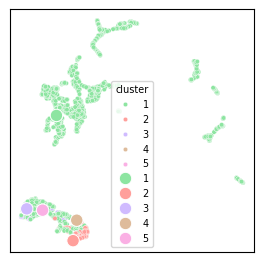

C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:124: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:125: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)


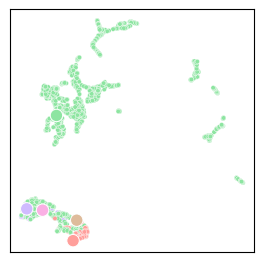

In [121]:
methods = ['mds','tsne', 'pca', 'umap', 'isomap']
# for method in methods: #method = 'isomap'
method = 'umap'
# for the full protein with linker
data_file = 'D:/Desktop/clusters_new/clusters_new/wl/wl_dit.dat'
df, distance_matrix = parse_rmsd_matrix(data_file = data_file, frame_num = 2000)
coords = reduce_rmsd_matrix(distance_matrix, method = method, perplexity = perplexity)
log_file = 'D:/Desktop/clusters_new/clusters_new/wl/cluster.log'
cluster_result = parse_gromos_cluster_log(log_file)
center_index = [153400, 33600,58500,76600,23100,46200,174400,4500,21600,48000,88700]
center_index = [137500, 1000, 38700, 17400, 39500]
plot_df, center_df, hue_order = add_cluster_col(df, cluster_result, center_index = center_index, frame_num = 2000)
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wl_analysis_legend', legend = True)
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wl_analysis', legend = False)

In [69]:
# for the full protein with linker
data_file = 'D:/Desktop/clusters_new/clusters_new/wl/wl_dit.dat'
df, distance_matrix = parse_rmsd_matrix(data_file = data_file, frame_num = 2000)
coords = reduce_rmsd_matrix(distance_matrix, method = method, perplexity = perplexity)
log_file = 'D:/Desktop/clusters_new/clusters_new/wl/cluster.log'
cluster_result = parse_gromos_cluster_log(log_file)
center_index = [153400, 33600,58500,76600,23100,46200,174400,4500,21600,48000,88700]
center_index = [137500, 1000, 38700, 17400, 39500]
plot_df, center_df, hue_order = add_cluster_col(df, cluster_result, center_index = center_index, frame_num = 2000)

C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'


In [84]:
df.loc['137500','1000']

1.5

C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:124: UserWarning: The palette list has more values (25) than needed (5), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:125: UserWarning: The palette list has more values (25) than needed (5), which may not be intended.
  scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)


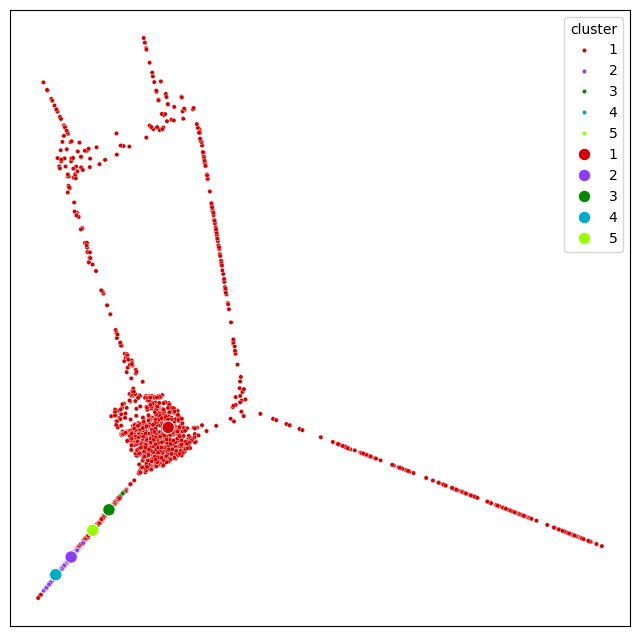

C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:124: UserWarning: The palette list has more values (25) than needed (5), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:125: UserWarning: The palette list has more values (25) than needed (5), which may not be intended.
  scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)


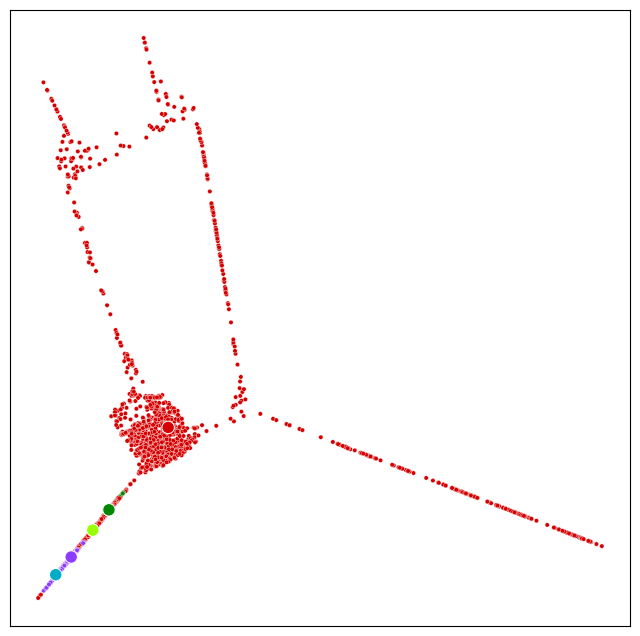

In [70]:
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wl_analysis', legend = True)
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wl_analysis', legend = False)

In [73]:
# for the full protein with linker
data_file = 'D:/Desktop/clusters_new/clusters_new/wol/wol_dit.dat'
df, distance_matrix = parse_rmsd_matrix(data_file = data_file, frame_num = 2000)
coords = reduce_rmsd_matrix(distance_matrix)
log_file = 'D:/Desktop/clusters_new/clusters_new/wol/cluster.log'
cluster_result = parse_gromos_cluster_log(log_file)
center_index = [153400, 33600,58500,76600,23100,46200,174400,4500,21600,48000,88700]
center_index = [167600, 57100, 40200, 63400]
plot_df, center_df, hue_order = add_cluster_col(df, cluster_result, center_index = center_index, frame_num = 2000)

D:\miniconda3\envs\plot\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'


In [91]:
import itertools
for x, y in itertools.combinations(center_index, 2):
    print(x,y, df.loc[f'{x}',f'{y}'])

167600 57100 1.32
167600 40200 1.02
167600 63400 1.32
57100 40200 1.38
57100 63400 0.842
40200 63400 1.74


In [104]:
method = 'cealign'
atom = '////CA'
ncealign = ''
for x, y in itertools.combinations([i for i in range(4)], 2):
    # print(f'super cluster_top_{x}////CA, cluster_top_{y}////CA;')
    print(f'{method} cluster_top_{x}{atom}, cluster_top_{y}{atom}{ncealign};')

cealign cluster_top_0////CA, cluster_top_1////CA;
cealign cluster_top_0////CA, cluster_top_2////CA;
cealign cluster_top_0////CA, cluster_top_3////CA;
cealign cluster_top_1////CA, cluster_top_2////CA;
cealign cluster_top_1////CA, cluster_top_3////CA;
cealign cluster_top_2////CA, cluster_top_3////CA;


C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:124: UserWarning: The palette list has more values (25) than needed (4), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:125: UserWarning: The palette list has more values (25) than needed (4), which may not be intended.
  scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)


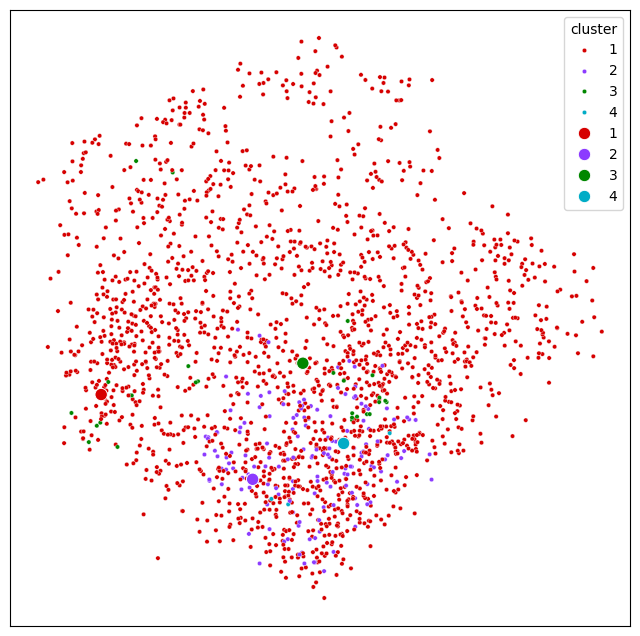

C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:124: UserWarning: The palette list has more values (25) than needed (4), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\2380095417.py:125: UserWarning: The palette list has more values (25) than needed (4), which may not be intended.
  scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)


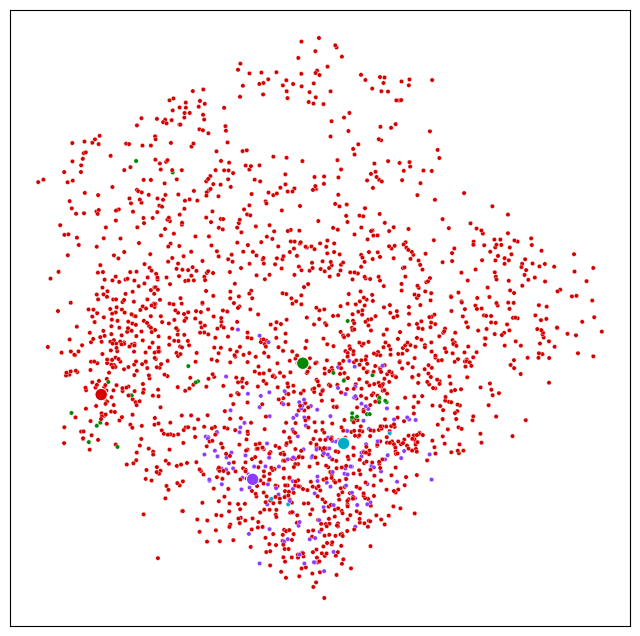

In [74]:
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wol_analysis', legend = True)
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wol_analysis', legend = False)

D:\miniconda3\envs\plot\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  for i in members_list:plot_df.loc[f'{i}','cluster'] = f'{cl_id}'
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:124: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:125: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  scatter1 = sns.scatterplot(c

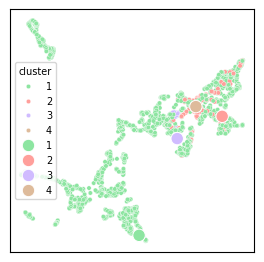

C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:124: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  scatter  = sns.scatterplot(plot_df, x = 'x', y = 'y',hue = 'cluster',hue_order = hue_order, s=10, palette = my_palette)
C:\Users\jianq\AppData\Local\Temp\ipykernel_23164\1141898129.py:125: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  scatter1 = sns.scatterplot(center_df, x = 'x', y = 'y', hue = 'cluster',hue_order = hue_order, s=80, palette = my_palette)


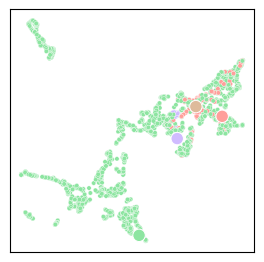

In [122]:
methods = ['mds','tsne', 'pca', 'umap', 'isomap']
# for method in methods[1:]: #method = 'isomap'
    # for the full protein with linker
method = 'umap'
data_file = 'D:/Desktop/clusters_new/clusters_new/wol/wol_dit.dat'
df, distance_matrix = parse_rmsd_matrix(data_file = data_file, frame_num = 2000)
coords = reduce_rmsd_matrix(distance_matrix, method = method, perplexity = perplexity)
log_file = 'D:/Desktop/clusters_new/clusters_new/wol/cluster.log'
cluster_result = parse_gromos_cluster_log(log_file)
center_index = [153400, 33600,58500,76600,23100,46200,174400,4500,21600,48000,88700]
center_index = [167600, 57100, 40200, 63400]
plot_df, center_df, hue_order = add_cluster_col(df, cluster_result, center_index = center_index, frame_num = 2000)
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wol_analysis_legend', legend = True)
visualiza_rmsd_matrix(plot_df, center_df, hue_order =hue_order, center_point = center_index, save_file = 'wol_analysis', legend = False)